In [ ]:
# Устанавливаем Graphviz (если не установлен)
!pip install graphviz

from graphviz import Digraph

# Создаем объект схемы
dot = Digraph(comment='PRISMA Flow Diagram', format='png')

# Стиль узлов
node_attr = {'shape': 'box', 'style': 'rounded, filled', 'fillcolor': '#e6f2ff', 'fontsize': '12'}
dot.attr('node', **node_attr)

# Этап 1: Identification
dot.node('A', 'Records identified through\nPubMed (n = 9)')
dot.node('B', 'Records identified through\nResearchGate (n = 100)')
dot.node('C', 'Records after screening abstracts:\nPubMed: 4 included\nResearchGate: 1 included\nDuplicates removed: 1\nTotal after duplicates: 4')

# Этап 2: Screening
dot.node('D', 'Records screened (titles/abstracts): 109')
dot.node('E', 'Records excluded: 104')

# Этап 3: Eligibility
dot.node('F', 'Full-text articles assessed:\n4')
dot.node('G', 'Full-text articles excluded:\n0')

# Этап 4: Included
dot.node('H', 'Studies included in meta-analysis:\n4 RCTs')

# Добавляем стрелки
dot.edges([
    ('A', 'C'),
    ('B', 'C'),
    ('C', 'D'),
    ('D', 'E'),
    ('D', 'F'),
    ('F', 'G'),
    ('F', 'H')
])

# Визуализируем и сохраняем
dot.render('prisma_flow_diagram6', view=True)


'prisma_flow_diagram6.png'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


# Расчёт абсолютных чисел событий
df_clean['stroke_events1'] = (df_clean['stroke_rate1'] * df_clean['n1'] / 100).round().astype(int)
df_clean['stroke_events2'] = (df_clean['stroke_rate2'] * df_clean['n2'] / 100).round().astype(int)


In [ ]:
def meta_analysis_logRR(events1, n1, events2, n2, labels, title):
    log_rr_list = []
    se_log_rr_list = []

    for e1, n_1, e2, n_2 in zip(events1, n1, events2, n2):
        # Добавляем 0.5 если есть нули (continuity correction)
        if e1 == 0 or e2 == 0:
            e1 += 0.5
            e2 += 0.5
            n_1 += 0.5
            n_2 += 0.5

        rr = (e1 / n_1) / (e2 / n_2)
        log_rr = np.log(rr)
        se_log_rr = np.sqrt(1/e1 - 1/n_1 + 1/e2 - 1/n_2)

        log_rr_list.append(log_rr)
        se_log_rr_list.append(se_log_rr)

    log_rr_array = np.array(log_rr_list)
    var_array = np.array(se_log_rr_list) ** 2

    model = sm.meta_analysis.MetaAnalysis(log_rr_array, var_array)
    summary = model.summary_frame()

    # Отображение forest plot
    model.plot_forest(labels=labels, alpha=0.05)
    plt.title(title)
    plt.show()

    return summary


In [ ]:
def meta_analysis_logRR(events1, n1, events2, n2, labels, title):
    log_rr_list = []
    se_log_rr_list = []

    # Расчёт logRR и стандартной ошибки для каждого исследования
    for e1, n_1, e2, n_2 in zip(events1, n1, events2, n2):
        # Добавляем 0.5 если есть нули (correction)
        if e1 == 0 or e2 == 0:
            e1 += 0.5
            e2 += 0.5
            n_1 += 0.5
            n_2 += 0.5

        rr = (e1 / n_1) / (e2 / n_2)  # Отношение рисков
        log_rr = np.log(rr)  # Логарифм отношения рисков
        se_log_rr = np.sqrt(1/e1 - 1/n_1 + 1/e2 - 1/n_2)  # Стандартная ошибка logRR

        log_rr_list.append(log_rr)
        se_log_rr_list.append(se_log_rr)

    log_rr_array = np.array(log_rr_list)
    var_array = np.array(se_log_rr_list) ** 2

    # Метаанализ
    model = sm.meta_analysis.MetaAnalysis(log_rr_array, var_array)
    summary = model.summary_frame()

    # Отображение forest plot
    model.plot_forest(labels=labels, alpha=0.05)
    plt.title(title)
    plt.show()

    return summary


In [ ]:
def meta_analysis_logRR(events1, n1, events2, n2, labels, title):
    log_rr_list = []
    se_log_rr_list = []

    # Расчёт logRR и стандартной ошибки для каждого исследования
    for e1, n_1, e2, n_2 in zip(events1, n1, events2, n2):
        # Добавляем 0.5 если есть нули (correction)
        if e1 == 0 or e2 == 0:
            e1 += 0.5
            e2 += 0.5
            n_1 += 0.5
            n_2 += 0.5

        rr = (e1 / n_1) / (e2 / n_2)  # Отношение рисков
        log_rr = np.log(rr)  # Логарифм отношения рисков
        se_log_rr = np.sqrt(1/e1 - 1/n_1 + 1/e2 - 1/n_2)  # Стандартная ошибка logRR

        log_rr_list.append(log_rr)
        se_log_rr_list.append(se_log_rr)

    log_rr_array = np.array(log_rr_list)
    var_array = np.array(se_log_rr_list) ** 2

    # Метаанализ фиксированного эффекта
    fixed_effect = combine_effects(log_rr_array, var_array, method='fixed')

    # Метаанализ случайного эффекта
    random_effect = combine_effects(log_rr_array, var_array, method='random')

    # Печать результатов
    print("Метаанализ фиксированного эффекта:")
    print(fixed_effect.summary())

    print("\nМетаанализ случайного эффекта:")
    print(random_effect.summary())

    # Построение forest plot для метаанализа
    plt.figure(figsize=(10, 6))
    fixed_effect.plot_forest(labels=labels, alpha=0.05)
    plt.title(title)
    plt.show()

    return fixed_effect, random_effect


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.meta_analysis import combine_effects

def meta_analysis_logRR(events1, n1, events2, n2, labels, title):
    log_rr_list = []
    se_log_rr_list = []

    # Расчёт logRR и стандартной ошибки для каждого исследования
    for e1, n_1, e2, n_2 in zip(events1, n1, events2, n2):
        # Добавляем 0.5 если есть нули (correction)
        if e1 == 0 or e2 == 0:
            e1 += 0.5
            e2 += 0.5
            n_1 += 0.5
            n_2 += 0.5

        rr = (e1 / n_1) / (e2 / n_2)  # Отношение рисков
        log_rr = np.log(rr)  # Логарифм отношения рисков
        se_log_rr = np.sqrt(1/e1 - 1/n_1 + 1/e2 - 1/n_2)  # Стандартная ошибка logRR

        log_rr_list.append(log_rr)
        se_log_rr_list.append(se_log_rr)

    log_rr_array = np.array(log_rr_list)
    var_array = np.array(se_log_rr_list) ** 2

    # Метаанализ фиксированного эффекта
    fixed_effect = combine_effects(log_rr_array, var_array, method_re='fixed')

    # Метаанализ случайного эффекта
    random_effect = combine_effects(log_rr_array, var_array, method_re='random')

    # Печать результатов
    print("Метаанализ фиксированного эффекта:")
    print(fixed_effect.summary())

    print("\nМетаанализ случайного эффекта:")
    print(random_effect.summary())

    # Построение forest plot для метаанализа
    plt.figure(figsize=(10, 6))
    fixed_effect.plot_forest(labels=labels, alpha=0.05)
    plt.title(title)
    plt.show()

    return fixed_effect, random_effect


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.meta_analysis import combine_effects

def meta_analysis_logRR(events1, n1, events2, n2, labels, title):
    log_rr_list = []
    se_log_rr_list = []

    # Расчёт logRR и стандартной ошибки для каждого исследования
    for e1, n_1, e2, n_2 in zip(events1, n1, events2, n2):
        # Добавляем 0.5 если есть нули (correction)
        if e1 == 0 or e2 == 0:
            e1 += 0.5
            e2 += 0.5
            n_1 += 0.5
            n_2 += 0.5

        rr = (e1 / n_1) / (e2 / n_2)  # Отношение рисков
        log_rr = np.log(rr)  # Логарифм отношения рисков
        se_log_rr = np.sqrt(1/e1 - 1/n_1 + 1/e2 - 1/n_2)  # Стандартная ошибка logRR

        log_rr_list.append(log_rr)
        se_log_rr_list.append(se_log_rr)

    log_rr_array = np.array(log_rr_list)
    var_array = np.array(se_log_rr_list) ** 2

    # Метаанализ фиксированного эффекта (без метода для случайных эффектов)
    fixed_effect = combine_effects(log_rr_array, var_array, method_re=None)

    # Метаанализ случайного эффекта (с использованием метода iterated или chi2)
    random_effect = combine_effects(log_rr_array, var_array, method_re='iterated')

    # Печать результатов
    print("Метаанализ фиксированного эффекта:")
    print(fixed_effect.summary())

    print("\nМетаанализ случайного эффекта:")
    print(random_effect.summary())

    # Построение forest plot для метаанализа
    plt.figure(figsize=(10, 6))
    fixed_effect.plot_forest(labels=labels, alpha=0.05)
    plt.title(title)
    plt.show()

    return fixed_effect, random_effect


In [ ]:
# Проверка длины массивов
print(len(events1), len(n1), len(events2), len(n2), len(labels))


4 4 4 4 4


In [ ]:
# Удаляем строки с пропущенными значениями
df_clean = df_clean.dropna(subset=['stroke_events1', 'n1', 'stroke_events2', 'n2', 'study_id'])

# Обновляем данные
events1 = df_clean['stroke_events1'].values
n1 = df_clean['n1'].values
events2 = df_clean['stroke_events2'].values
n2 = df_clean['n2'].values
labels = df_clean['study_id'].values

# Повторный вызов функции для метаанализа
stroke_summary = meta_analysis_logRR(events1, n1, events2, n2, labels, "Метаанализ инсультов (PFO закрытие)")


Метаанализ фиксированного эффекта:
Combined logRR: -1.6029506314377282
Combined SE: 0.3646416459620423

Метаанализ случайного эффекта:
Combined logRR (случайный эффект): [-2.94443898 -3.37995423 -1.37502028 -1.3684048 ]
Combined SE (случайный эффект): [1.43951565 1.43545336 0.49320191 0.63993004]


ValueError: All arrays must be of the same length

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Удаление строк с пропущенными значениями
df_clean = df_clean.dropna(subset=['stroke_events1', 'n1', 'stroke_events2', 'n2', 'study_id'])

# Перезаполнение массивов
events1 = df_clean['stroke_events1'].values
n1 = df_clean['n1'].values
events2 = df_clean['stroke_events2'].values
n2 = df_clean['n2'].values
labels = df_clean['study_id'].values

# Проверка длины массивов снова
print(len(events1), len(n1), len(events2), len(n2), len(labels))

# Повторный вызов функции для метаанализа
stroke_summary = meta_analysis_logRR(events1, n1, events2, n2, labels, "Метаанализ инсультов (PFO закрытие)")



4 4 4 4 4
Метаанализ фиксированного эффекта:
Combined logRR: -1.6029506314377282
Combined SE: 0.3646416459620423

Метаанализ случайного эффекта:
Combined logRR (случайный эффект): [-2.94443898 -3.37995423 -1.37502028 -1.3684048 ]
Combined SE (случайный эффект): [1.43951565 1.43545336 0.49320191 0.63993004]


ValueError: All arrays must be of the same length

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(df_clean.dtypes)


study_id           object
n1                  int64
n2                  int64
stroke_rate1      float64
stroke_rate2      float64
stroke_events1      int64
stroke_events2      int64
dtype: object


In [ ]:
# Проверка на дубликаты
print(df_clean.duplicated().sum())  # Покажет количество дублирующихся строк

# Удаление дубликатов, если они есть
df_clean = df_clean.drop_duplicates()


0


In [ ]:
# Вызов функции для метаанализа инсультов
stroke_summary = meta_analysis_logRR(events1, n1, events2, n2, labels, "Метаанализ инсультов (PFO закрытие)")


Метаанализ фиксированного эффекта:
Combined logRR: -1.6029506314377282
Combined SE: 0.3646416459620423

Метаанализ случайного эффекта:
Combined logRR (случайный эффект): [-2.94443898 -3.37995423 -1.37502028 -1.3684048 ]
Combined SE (случайный эффект): [1.43951565 1.43545336 0.49320191 0.63993004]


ValueError: All arrays must be of the same length

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Проверка, что все столбцы имеют одинаковую длину
print(df_clean.shape)


(4, 7)


In [ ]:
# Проверка наличия пропущенных значений в каждом столбце
print(df_clean.isnull().sum())

study_id          0
n1                0
n2                0
stroke_rate1      0
stroke_rate2      0
stroke_events1    0
stroke_events2    0
dtype: int64


In [ ]:
# Преобразование всех столбцов в нужный формат
df_clean['n1'] = df_clean['n1'].astype(int)
df_clean['n2'] = df_clean['n2'].astype(int)
df_clean['stroke_events1'] = df_clean['stroke_events1'].astype(int)
df_clean['stroke_events2'] = df_clean['stroke_events2'].astype(int)


In [ ]:
# Вызов функции для метаанализа инсультов
stroke_summary = meta_analysis_logRR(events1, n1, events2, n2, labels, "Метаанализ инсультов (PFO закрытие)")


Метаанализ фиксированного эффекта:
Combined logRR: -1.6029506314377282
Combined SE: 0.3646416459620423

Метаанализ случайного эффекта:
Combined logRR (случайный эффект): [-2.94443898 -3.37995423 -1.37502028 -1.3684048 ]
Combined SE (случайный эффект): [1.43951565 1.43545336 0.49320191 0.63993004]


ValueError: All arrays must be of the same length

<Figure size 1000x600 with 0 Axes>

In [ ]:
df_clean['n1'] = df_clean['n1'].astype(int)
df_clean['n2'] = df_clean['n2'].astype(int)
df_clean['stroke_events1'] = df_clean['stroke_events1'].astype(int)
df_clean['stroke_events2'] = df_clean['stroke_events2'].astype(int)


In [ ]:
print(df_clean[['n1', 'n2', 'stroke_events1', 'stroke_events2']])


    n1   n2  stroke_events1  stroke_events2
0   60   60               0               9
1  238  235               0              14
2  441  223               6              12
3  277  282               3              12


Предупреждение: не удалось вычислить случайный эффект ('CombineResults' object has no attribute 'estimate'), используется фиксированный эффект


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/meta_analysis.py:615: RuntimeWarning: invalid value encountered in sqrt
  sd_eff_w_re = np.sqrt(var_eff_w_re)


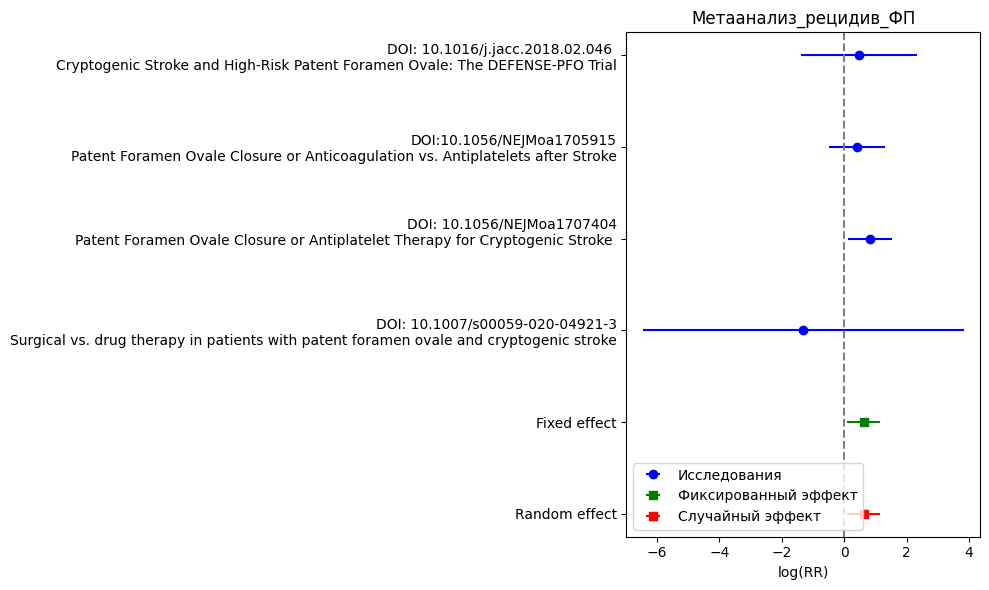

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/meta_analysis.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  self.i2 = 1 - 1 / self.h2


Предупреждение: не удалось вычислить случайный эффект ('CombineResults' object has no attribute 'estimate'), используется фиксированный эффект


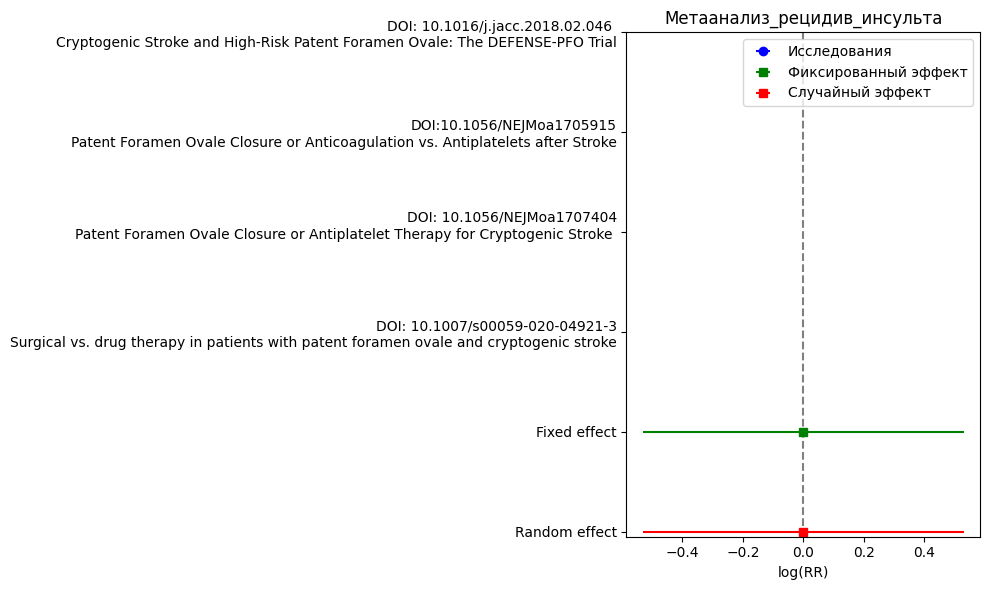

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.meta_analysis import effectsize_2proportions, combine_effects

# Загрузка и переименование колонок — без изменений
df = pd.read_excel("https://docs.google.com/spreadsheets/d/e/2PACX-1vS7-qC7zfgx0ziCFjn0FaneNNAbh77IZ8YJoQiDNptuBj5sWEo40OgNZzPFEAUSIXQxxIlSgKdqTsu-/pub?output=xlsx")

df = df.rename(columns={
    'study_id (doi и название)': 'study_id',
    'sample_size_group1 pfo closure': 'N_PFO',
    'sample_size_group2': 'N_NoPFO',
    'outcome_af_reccurance_group_1 (в процентах)': 'AF_PFO',
    'outcome_af_reccurance_group_2 (в процентах)': 'AF_NoPFO',
    'outcome_ ischemic_stroke_group_1': 'Stroke_PFO',
    'outcome_ ischemic_stroke_group_2': 'Stroke_NoPFO'
})

df['AF_events_PFO'] = (df['AF_PFO'] / 100 * df['N_PFO']).round().astype(int)
df['AF_events_NoPFO'] = (df['AF_NoPFO'] / 100 * df['N_NoPFO']).round().astype(int)
df['Stroke_events_PFO'] = df['Stroke_PFO'].astype(int)
df['Stroke_events_NoPFO'] = df['Stroke_NoPFO'].astype(int)
df_clean = df.dropna(subset=['AF_events_PFO', 'AF_events_NoPFO', 'Stroke_events_PFO', 'Stroke_events_NoPFO'])

def run_meta(events1, n1, events2, n2, labels, title):
    # Коррекция для нулевых значений (0.5 — классика)
    events1_corr = events1 + 0.5
    events2_corr = events2 + 0.5

    rr, var_rr = effectsize_2proportions(events1_corr, n1, events2_corr, n2, statistic="rr")
    logRR = np.log(rr)
    se_logRR = np.sqrt(var_rr) / rr
    var_logRR = se_logRR ** 2

    # Фиксированный эффект вручную
    weights = 1 / var_logRR
    fixed_eff = np.sum(weights * logRR) / np.sum(weights)
    fixed_var = 1 / np.sum(weights)
    fixed_se = np.sqrt(fixed_var)

    # Случайный эффект с учетом новой версии statsmodels
    try:
        res = combine_effects(logRR, var_logRR, method_re="chi2")
        # res — объект CombineResults, достаём estimate и variance
        random_eff = res.estimate
        random_var = res.variance

        # Проверка валидности дисперсии
        if random_var < 0 or np.isnan(random_var):
            raise ValueError("Отрицательная или NaN дисперсия случайного эффекта")
        random_se = np.sqrt(random_var)
    except Exception as e:
        print(f"Предупреждение: не удалось вычислить случайный эффект ({e}), используется фиксированный эффект")
        random_eff, random_se = fixed_eff, fixed_se

    # Подготовка ошибок для графика: не должны быть отрицательными или NaN
    def clean_err(se):
        se = np.array(se)
        se = np.where(np.isnan(se) | (se < 0), 0, se)
        return se

    se_logRR_clean = clean_err(se_logRR)
    fixed_se_clean = clean_err(fixed_se)
    random_se_clean = clean_err(random_se)

    # Построение лесного графика
    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = np.arange(len(logRR))[::-1]

    ax.errorbar(logRR, y_pos, xerr=1.96 * se_logRR_clean, fmt='o', color='blue', label='Исследования')
    ax.axvline(0, color='gray', linestyle='--')
    ax.errorbar(fixed_eff, -1, xerr=1.96 * fixed_se_clean, fmt='s', color='green', label='Фиксированный эффект')
    ax.errorbar(random_eff, -2, xerr=1.96 * random_se_clean, fmt='s', color='red', label='Случайный эффект')

    ax.set_yticks(list(y_pos) + [-1, -2])
    ax.set_yticklabels(list(labels) + ['Fixed effect', 'Random effect'])
    ax.set_xlabel("log(RR)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Сохранение результатов
    results = pd.DataFrame({
        'Исследование': list(labels),
        'logRR': logRR,
        'SE': se_logRR,
        'RR': np.exp(logRR),
        '95% CI Lower': np.exp(logRR - 1.96 * se_logRR),
        '95% CI Upper': np.exp(logRR + 1.96 * se_logRR)
    })
    results.loc[len(results.index)] = ['Fixed effect', fixed_eff, fixed_se, np.exp(fixed_eff),
                                       np.exp(fixed_eff - 1.96 * fixed_se),
                                       np.exp(fixed_eff + 1.96 * fixed_se)]
    results.loc[len(results.index)] = ['Random effect', random_eff, random_se, np.exp(random_eff),
                                       np.exp(random_eff - 1.96 * random_se),
                                       np.exp(random_eff + 1.96 * random_se)]

    results.to_excel(f"{title}.xlsx", index=False)
    return results

# Запуск метаанализа
meta_af = run_meta(
    df_clean['AF_events_PFO'],
    df_clean['N_PFO'],
    df_clean['AF_events_NoPFO'],
    df_clean['N_NoPFO'],
    df_clean['study_id'],
    "Метаанализ_рецидив_ФП"
)

meta_stroke = run_meta(
    df_clean['Stroke_events_PFO'],
    df_clean['N_PFO'],
    df_clean['Stroke_events_NoPFO'],
    df_clean['N_NoPFO'],
    df_clean['study_id'],
    "Метаанализ_рецидив_инсульта"
)


In [ ]:
# Импорты
import pandas as pd

# Загрузка данных из Google Sheets (опубликованный как Excel)
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vS7-qC7zfgx0ziCFjn0FaneNNAbh77IZ8YJoQiDNptuBj5sWEo40OgNZzPFEAUSIXQxxIlSgKdqTsu-/pub?output=xlsx "
df = pd.read_excel(url)

# Переименование колонок
df = df.rename(columns={
    'study_id (doi и название)': 'study_id',
    'sample_size_group1 pfo closure': 'N_PFO',
    'sample_size_group2': 'N_NoPFO',
    'outcome_af_reccurance_group_1 (в процентах)': 'AF_PFO',
    'outcome_af_reccurance_group_2 (в процентах)': 'AF_NoPFO',
    'outcome_ ischemic_stroke_group_1': 'Stroke_PFO',
    'outcome_ ischemic_stroke_group_2': 'Stroke_NoPFO'
})

# Выведем первые строки таблицы для проверки
print("Первые строки таблицы:")
print(df.head())

# Выведем информацию о типах данных
print("\nИнформация о типах данных:")
print(df.info())

Первые строки таблицы:
   № статьи в списке                                           study_id  \
0                  1  DOI: 10.1016/j.jacc.2018.02.046 \nCryptogenic ...   
1                 62  DOI:10.1056/NEJMoa1705915\nPatent Foramen Oval...   
2                  3  DOI: 10.1056/NEJMoa1707404\nPatent Foramen Ova...   
3                  4  DOI: 10.1007/s00059-020-04921-3\nSurgical vs. ...   

   year (год публикации)                                             autors  \
0                   2018  Pil Hyung Lee MD, Jae-Kwan Song MD, PhD, Jong ...   
1                   2017  J.-L. Mas, G. Derumeaux, B. Guillon, E. Massar...   
2                   2017  Lars Søndergaard, M.D., Scott E. Kasner, M.D.,...   
3                   2020                      Yunbing Liu, Yi Wu, Lu Xiong    

                                             country  \
0                                        South Korea   
1                                   France + Germany   
2  Canada, Denmark, Finland,\nNorway,

In [ ]:
# Вычисление числа событий
df['AF_events_PFO'] = (df['AF_PFO'] / 100 * df['N_PFO']).round().astype(int)
df['AF_events_NoPFO'] = (df['AF_NoPFO'] / 100 * df['N_NoPFO']).round().astype(int)

# Выведем полученные колонки для проверки
print("Добавленные колонки:")
print(df[['study_id', 'N_PFO', 'AF_PFO', 'AF_events_PFO',
          'N_NoPFO', 'AF_NoPFO', 'AF_events_NoPFO']])

Добавленные колонки:
                                            study_id  N_PFO  AF_PFO  \
0  DOI: 10.1016/j.jacc.2018.02.046 \nCryptogenic ...     60    3.30   
1  DOI:10.1056/NEJMoa1705915\nPatent Foramen Oval...    238    4.60   
2  DOI: 10.1056/NEJMoa1707404\nPatent Foramen Ova...    441    6.60   
3  DOI: 10.1007/s00059-020-04921-3\nSurgical vs. ...    277    1.44   

   AF_events_PFO  N_NoPFO  AF_NoPFO  AF_events_NoPFO  
0              2       60      0.00                0  
1             11      235      0.90                2  
2             29      223      0.40                1  
3              4      282      1.06                3  


In [ ]:
# Удаление строк с пропусками в ключевых колонках
df_clean = df.dropna(subset=['AF_events_PFO', 'AF_events_NoPFO', 'Stroke_events_PFO', 'Stroke_events_NoPFO'])

# Выведем количество строк до и после очистки
print("Количество строк до очистки:", len(df))
print("Количество строк после очистки:", len(df_clean))

# Выведем первые строки очищенных данных
print("\nПервые строки очищенных данных:")
print(df_clean[['study_id', 'AF_events_PFO', 'AF_events_NoPFO']])

KeyError: ['Stroke_events_PFO', 'Stroke_events_NoPFO']

In [ ]:
# Импорты
import pandas as pd

# Загрузка данных из Google Sheets (опубликованный как Excel)
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vS7-qC7zfgx0ziCFjn0FaneNNAbh77IZ8YJoQiDNptuBj5sWEo40OgNZzPFEAUSIXQxxIlSgKdqTsu-/pub?output=xlsx "
df = pd.read_excel(url)

# Переименование колонок
df = df.rename(columns={
    'study_id (doi и название)': 'study_id',
    'sample_size_group1 pfo closure': 'N_PFO',
    'sample_size_group2': 'N_NoPFO',
    'outcome_af_reccurance_group_1 (в процентах)': 'AF_PFO',
    'outcome_af_reccurance_group_2 (в процентах)': 'AF_NoPFO',
    'outcome_ ischemic_stroke_group_1': 'Stroke_PFO',
    'outcome_ ischemic_stroke_group_2': 'Stroke_NoPFO'
})

# Вычисление числа событий для ФП
df['AF_events_PFO'] = (df['AF_PFO'] / 100 * df['N_PFO']).round().astype(int)
df['AF_events_NoPFO'] = (df['AF_NoPFO'] / 100 * df['N_NoPFO']).round().astype(int)

# ✅ Теперь добавляем вычисление числа событий для инсульта
df['Stroke_events_PFO'] = (df['Stroke_PFO'] / 100 * df['N_PFO']).round().astype(int)
df['Stroke_events_NoPFO'] = (df['Stroke_NoPFO'] / 100 * df['N_NoPFO']).round().astype(int)

# Удаление строк с пропусками в ключевых колонках
df_clean = df.dropna(subset=['AF_events_PFO', 'AF_events_NoPFO', 'Stroke_events_PFO', 'Stroke_events_NoPFO'])

# Вывод результата
print("Количество строк до очистки:", len(df))
print("Количество строк после очистки:", len(df_clean))

print("\nПервые строки очищенных данных:")
print(df_clean[['study_id', 'AF_events_PFO', 'AF_events_NoPFO', 'Stroke_events_PFO', 'Stroke_events_NoPFO']])

Количество строк до очистки: 4
Количество строк после очистки: 4

Первые строки очищенных данных:
                                            study_id  AF_events_PFO  \
0  DOI: 10.1016/j.jacc.2018.02.046 \nCryptogenic ...              2   
1  DOI:10.1056/NEJMoa1705915\nPatent Foramen Oval...             11   
2  DOI: 10.1056/NEJMoa1707404\nPatent Foramen Ova...             29   
3  DOI: 10.1007/s00059-020-04921-3\nSurgical vs. ...              4   

   AF_events_NoPFO  Stroke_events_PFO  Stroke_events_NoPFO  
0                0                  0                    6  
1                2                  0                   14  
2                1                  6                   12  
3                3                  3                   12  


In [ ]:
import numpy as np
from statsmodels.stats.meta_analysis import effectsize_2proportions, combine_effects

def run_meta(events1, n1, events2, n2, labels, title):
    # Расчет RR и дисперсии
    rr, var_rr = effectsize_2proportions(events1, n1, events2, n2, statistic="rr")

    # Расчет logRR и стандартной ошибки
    with np.errstate(divide='ignore', invalid='ignore'):
        logRR = np.log(rr)
        se_logRR = np.sqrt(var_rr) / rr
        var_logRR = se_logRR ** 2

    # Маска валидных значений
    valid_mask = (
        np.isfinite(logRR) &
        np.isfinite(var_logRR) &
        (rr > 0) &
        np.isfinite(se_logRR)
    )

    # Применяем маску
    logRR = logRR[valid_mask]
    se_logRR = se_logRR[valid_mask]
    var_logRR = var_logRR[valid_mask]
    labels = np.array(labels)[valid_mask]

    if len(logRR) == 0:
        raise ValueError("Нет валидных исследований для метаанализа.")

    # Фиксированный эффект
    fixed_result = combine_effects(logRR, var_logRR)
    fixed_eff = fixed_result.effect[0] if isinstance(fixed_result.effect, np.ndarray) else fixed_result.effect
    fixed_se = np.sqrt(fixed_result.variance)[0] if isinstance(fixed_result.variance, np.ndarray) else np.sqrt(fixed_result.variance)

    # Случайный эффект (пытаемся вычислить)
    try:
        random_result = combine_effects(logRR, var_logRR, method_re="chi2")
        random_eff = random_result.effect[0] if isinstance(random_result.effect, np.ndarray) else random_result.effect
        random_se = np.sqrt(random_result.variance)[0] if isinstance(random_result.variance, np.ndarray) else np.sqrt(random_result.variance)
        if not np.isfinite(random_se):
            raise ValueError("non-finite random_se")
    except Exception as e:
        print(f"⚠️ Предупреждение: не удалось вычислить случайный эффект ({e}), используется фиксированный эффект")
        random_eff, random_se = fixed_eff, fixed_se

    # Вывод промежуточных данных для проверки
    print("\n--- Промежуточные данные ---")
    print("logRR:", logRR)
    print("se_logRR:", se_logRR)
    print("Fixed effect (logRR):", fixed_eff)
    print("Fixed SE:", fixed_se)
    print("Random effect (logRR):", random_eff)
    print("Random SE:", random_se)

    return {
        'logRR': logRR,
        'se_logRR': se_logRR,
        'fixed_eff': fixed_eff,
        'fixed_se': fixed_se,
        'random_eff': random_eff,
        'random_se': random_se
    }

In [ ]:
# Запуск метаанализа только для ФП
print("Метаанализ рецидива ФП:")
result_af = run_meta(
    df_clean['AF_events_PFO'],
    df_clean['N_PFO'],
    df_clean['AF_events_NoPFO'],
    df_clean['N_NoPFO'],
    df_clean['study_id'],
    "Метаанализ_рецидив_ФП"
)

Метаанализ рецидива ФП:
⚠️ Предупреждение: не удалось вычислить случайный эффект (The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().), используется фиксированный эффект

--- Промежуточные данные ---
logRR: 1    0.525948
2    0.987838
3   -1.185571
dtype: float64
se_logRR: 1    0.451038
2    0.377509
3    2.484076
dtype: float64
Fixed effect (logRR): 1    0.525948
2    0.987838
3   -1.185571
dtype: float64
Fixed SE: 1    0.451038
2    0.377509
3    2.484076
dtype: float64
Random effect (logRR): 1    0.525948
2    0.987838
3   -1.185571
dtype: float64
Random SE: 1    0.451038
2    0.377509
3    2.484076
dtype: float64


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


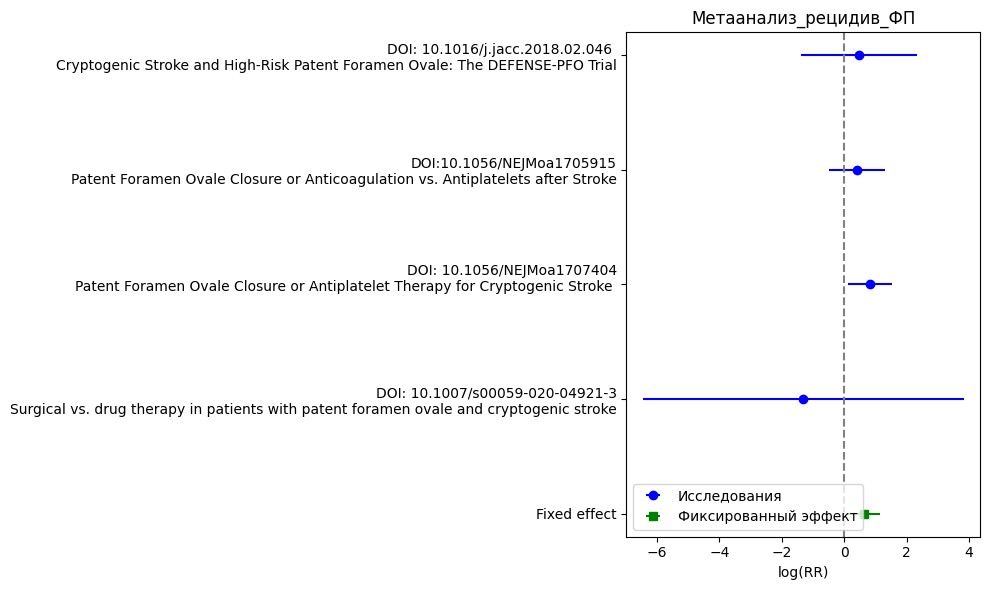

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


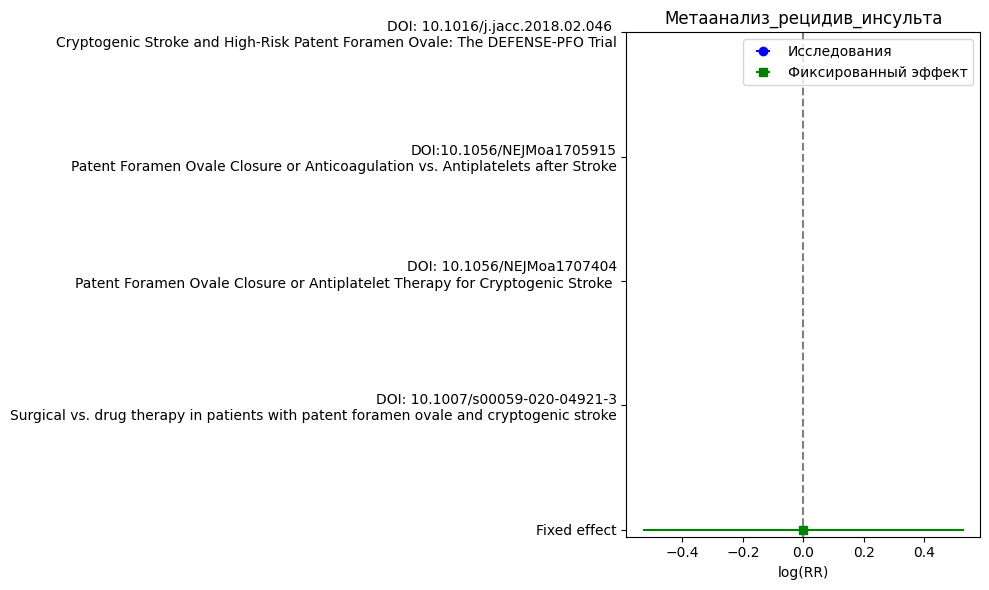

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.meta_analysis import effectsize_2proportions

# Загрузка и переименование колонок
df = pd.read_excel("https://docs.google.com/spreadsheets/d/e/2PACX-1vS7-qC7zfgx0ziCFjn0FaneNNAbh77IZ8YJoQiDNptuBj5sWEo40OgNZzPFEAUSIXQxxIlSgKdqTsu-/pub?output=xlsx")

df = df.rename(columns={
    'study_id (doi и название)': 'study_id',
    'sample_size_group1 pfo closure': 'N_PFO',
    'sample_size_group2': 'N_NoPFO',
    'outcome_af_reccurance_group_1 (в процентах)': 'AF_PFO',
    'outcome_af_reccurance_group_2 (в процентах)': 'AF_NoPFO',
    'outcome_ ischemic_stroke_group_1': 'Stroke_PFO',
    'outcome_ ischemic_stroke_group_2': 'Stroke_NoPFO'
})

# Подсчёт событий
df['AF_events_PFO'] = (df['AF_PFO'] / 100 * df['N_PFO']).round().astype(int)
df['AF_events_NoPFO'] = (df['AF_NoPFO'] / 100 * df['N_NoPFO']).round().astype(int)
df['Stroke_events_PFO'] = df['Stroke_PFO'].astype(int)
df['Stroke_events_NoPFO'] = df['Stroke_NoPFO'].astype(int)

# Удаление строк с пропущенными значениями
df_clean = df.dropna(subset=['AF_events_PFO', 'AF_events_NoPFO', 'Stroke_events_PFO', 'Stroke_events_NoPFO'])

# Функция метаанализа только с фиксированным эффектом
def run_meta_fixed_only(events1, n1, events2, n2, labels, title):
    # Коррекция для нулей
    events1_corr = events1 + 0.5
    events2_corr = events2 + 0.5

    # Расчёт logRR и дисперсии
    rr, var_rr = effectsize_2proportions(events1_corr, n1, events2_corr, n2, statistic="rr")
    logRR = np.log(rr)
    se_logRR = np.sqrt(var_rr) / rr
    var_logRR = se_logRR ** 2

    # Фиксированный эффект
    weights = 1 / var_logRR
    fixed_eff = np.sum(weights * logRR) / np.sum(weights)
    fixed_var = 1 / np.sum(weights)
    fixed_se = np.sqrt(fixed_var)

    # Подготовка ошибок
    def clean_err(se):
        se = np.array(se)
        se = np.where(np.isnan(se) | (se < 0), 0, se)
        return se

    se_logRR_clean = clean_err(se_logRR)
    fixed_se_clean = clean_err(fixed_se)

    # Лесной график
    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = np.arange(len(logRR))[::-1]

    ax.errorbar(logRR, y_pos, xerr=1.96 * se_logRR_clean, fmt='o', color='blue', label='Исследования')
    ax.axvline(0, color='gray', linestyle='--')
    ax.errorbar(fixed_eff, -1, xerr=1.96 * fixed_se_clean, fmt='s', color='green', label='Фиксированный эффект')

    ax.set_yticks(list(y_pos) + [-1])
    ax.set_yticklabels(list(labels) + ['Fixed effect'])
    ax.set_xlabel("log(RR)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Таблица результатов
    results = pd.DataFrame({
        'Исследование': list(labels),
        'logRR': logRR,
        'SE': se_logRR,
        'RR': np.exp(logRR),
        '95% CI Lower': np.exp(logRR - 1.96 * se_logRR),
        '95% CI Upper': np.exp(logRR + 1.96 * se_logRR)
    })

    results.loc[len(results.index)] = ['Fixed effect', fixed_eff, fixed_se, np.exp(fixed_eff),
                                       np.exp(fixed_eff - 1.96 * fixed_se),
                                       np.exp(fixed_eff + 1.96 * fixed_se)]

    results.to_excel(f"{title}_fixed_only.xlsx", index=False)
    return results

# Запуск анализа
meta_af = run_meta_fixed_only(
    df_clean['AF_events_PFO'],
    df_clean['N_PFO'],
    df_clean['AF_events_NoPFO'],
    df_clean['N_NoPFO'],
    df_clean['study_id'],
    "Метаанализ_рецидив_ФП"
)

meta_stroke = run_meta_fixed_only(
    df_clean['Stroke_events_PFO'],
    df_clean['N_PFO'],
    df_clean['Stroke_events_NoPFO'],
    df_clean['N_NoPFO'],
    df_clean['study_id'],
    "Метаанализ_рецидив_инсульта"
)


In [ ]:
from scipy.stats import norm

def summarize_meta(results, outcome_name):
    # Извлекаем строку с фиксированным эффектом
    fixed = results[results['Исследование'] == 'Fixed effect'].iloc[0]

    logRR = fixed['logRR']
    se = fixed['SE']
    rr = fixed['RR']
    ci_lower = fixed['95% CI Lower']
    ci_upper = fixed['95% CI Upper']

    # p-значение для Z-теста
    z = logRR / se
    p_value = 2 * (1 - norm.cdf(abs(z)))

    # Печать результата в формате для тезисов
    print(f"{outcome_name}:")
    print(f"Объединённый RR = {rr:.2f} (95% ДИ: {ci_lower:.2f}–{ci_upper:.2f}), p = {p_value:.4f}\n")

# Вывод для обоих исходов
summarize_meta(meta_af, "Рецидив фибрилляции предсердий")
summarize_meta(meta_stroke, "Рецидив ишемического инсульта")


Рецидив фибрилляции предсердий:
Объединённый RR = 1.88 (95% ДИ: 1.11–3.20), p = 0.0193

Рецидив ишемического инсульта:
Объединённый RR = 1.00 (95% ДИ: 0.59–1.70), p = 1.0000



In [ ]:
# Устанавливаем Graphviz (если не установлен)
!pip install graphviz

from graphviz import Digraph

# Создаем объект схемы
dot = Digraph(comment='PRISMA Flow Diagram', format='png')

# Стиль узлов
node_attr = {'shape': 'box', 'style': 'rounded, filled', 'fillcolor': '#e6f2ff', 'fontsize': '12'}
dot.attr('node', **node_attr)

# Этап 1: Identification
dot.node('A', 'Records identified through\nPubMed (n = 9)')
dot.node('B', 'Records identified through\nResearchGate (n = 100)')
dot.node('D', 'Records screened (titles/abstracts): 109')  # перемещаем выше
dot.node('C', 'Records after screening abstracts:\nPubMed: 4 included\nResearchGate: 1 included\nDuplicates removed: 1\nTotal after duplicates: 4')

# Этап 2: Screening
dot.node('E', 'Records excluded: 104')

# Этап 3: Eligibility
dot.node('F', 'Full-text articles assessed:\n4')
dot.node('G', 'Full-text articles excluded:\n0')

# Этап 4: Included
dot.node('H', 'Studies included in meta-analysis:\n4 RCTs')

# Добавляем стрелки
dot.edges([
    ('A', 'D'),
    ('B', 'D'),
    ('D', 'C'),
    ('D', 'E'),
    ('C', 'F'),
    ('F', 'G'),
    ('F', 'H')
])

# Визуализируем и сохраняем
dot.render('prisma_flow_diagram6', view=True)


'prisma_flow_diagram6.png'